#Creation of lignite/coal occupations dataset (subset of official ESCO occupations)

In [ ]:
import pandas as pd

df_esco = pd.read_csv("occupations_en.csv")

keywords = [
    "coal",
    "lignite",
    "carbon",
    "carbon mining"
    "lignite mining"
    "mine",
    "mining",
    "miner",
    "quarry",
    "quarrying",
    "surface miner",
    "underground miner",
    "fossil fuel",
    "thermal power",
    "power plant",
    "steam turbine",
    "boiler operator",
    "steam plant",
    "flue gas",
    "ash handling",
    "coking furnace",
    "heavy equipment",
    "dragline",
    "excavator",
    "mineral processing",
    "electric power",
    "electricity",
    "power generation"
    "electricity generation"
]

keyword_pattern = r"\b(?:" + "|".join(keywords) + r")\b"

# ISCO-08 codes
isco_codes = ["8111", "8112", "3117", "2146", "3131", "7233", "8182"]
isco_pattern = r"^(?:" + "|".join(isco_codes) + r")"

title_match = df_esco["preferredLabel"].str.contains(
    keyword_pattern, case=False, na=False, regex=True
)
alt_match = df_esco["altLabels"].str.contains(
    keyword_pattern, case=False, na=False, regex=True
)
desc_match = df_esco["description"].str.contains(
    keyword_pattern, case=False, na=False, regex=True
)

isco_group_match = (
    df_esco["iscoGroup"]
    .astype(str)
    .str.contains(isco_pattern, na=False, regex=True)
)
code_match = (
    df_esco["code"].astype(str).str.contains(isco_pattern, na=False, regex=True)
)

# Filtering & removal of obviously irrelevant/other forms of energy (e.g., solar, hydro)
combined_mask = (
    title_match | alt_match | desc_match | isco_group_match | code_match
)
lignite_df = df_esco[combined_mask].copy()

# Exclusion of other forms of RES/energy that might have been captured by general terms
exclude_terms = ["hydroelectric", "solar power", "geothermal", "wind energy"]
exclude_pattern = r"\b(?:" + "|".join(exclude_terms) + r")\b"

lignite_df = lignite_df[
    ~lignite_df["preferredLabel"].str.contains(
        exclude_pattern, case=False, na=False, regex=True
    )
]

# Storage to CSV
lignite_df = lignite_df.drop_duplicates(subset=["conceptUri"])
lignite_df.to_csv("lignite_occupations.csv", index=False, encoding="utf-8-sig")

print(f"Total Stored Occupations: {len(lignite_df)} ")

Total Stored Occupations: 122 


#Lignite Jobs Filtering from Skillab API

#Greece

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_greece_lignite_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

LOCATION_CODE = ["EL"]
OCCUPATION_IDS = lignite_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=EL and occupation_ids (OR logic)
    against the full list of lignite occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [EL]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} lignite occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['EL'], occupation_ids=(122 lignite occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [EL]:   3%|▎         | 100/3582 [00:00<00:00, 1619422.39job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [EL]:   6%|▌         | 200/3582 [00:03<00:57, 59.19job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certific

Total jobs collected: 3582
Saved job data to skillab_jobs_greece_lignite_occupations.json


#Germany

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_germany_lignite_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

LOCATION_CODE = ["DE"]
OCCUPATION_IDS = lignite_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=DE and occupation_ids (OR logic)
    against the full list of lignite occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [DE]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} lignite occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['DE'], occupation_ids=(122 lignite occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(



Page 1 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


...


Page 498 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [DE]:  98%|█████████▊| 49800/50889 [4:27:14<12:30,  1.45job/s, pages=498]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [DE]:  98%|█████████▊| 49900/50889 [4:28:00<10:11,  1.62job/s, pages=499]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding


Page 507 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [DE]: 100%|█████████▉| 50700/50889 [4:33:04<01:59,  1.58job/s, pages=507]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [DE]: 100%|█████████▉| 50800/50889 [4:33:12<00:41,  2.13job/s, pages=508]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding

Total jobs collected: 50889
Saved job data to skillab_jobs_germany_lignite_occupations.json


#France

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_france_lignite_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

LOCATION_CODE = ["FR"]
OCCUPATION_IDS = lignite_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=FR and occupation_ids (OR logic)
    against the full list of lignite occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [FR]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} lignite occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['FR'], occupation_ids=(122 lignite occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [FR]:   0%|          | 100/42674 [00:00<00:00, 2267191.35job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [FR]:   0%|          | 200/42674 [01:48<6:22:44,  1.85job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding cert


Page 31 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


...


Page 348 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [FR]:  82%|████████▏ | 34800/42674 [3:00:18<1:37:01,  1.35job/s, pages=348]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [FR]:  82%|████████▏ | 34900/42674 [3:00:21<1:08:21,  1.90job/s, pages=349]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Ad


Page 374 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [FR]:  88%|████████▊ | 37400/42674 [3:08:42<43:19,  2.03job/s, pages=374]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [FR]:  88%|████████▊ | 37500/42674 [3:08:53<32:23,  2.66job/s, pages=375]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding

Total jobs collected: 42674
Saved job data to skillab_jobs_france_lignite_occupations.json


#Sweden

In [8]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_sweden_lignite_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

LOCATION_CODE = ["SE"]
OCCUPATION_IDS = lignite_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=SE and occupation_ids (OR logic)
    against the full list of lignite occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [SE]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} lignite occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['SE'], occupation_ids=(122 lignite occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(



Page 1 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


...


Page 303 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [SE]:  99%|█████████▊| 30300/30691 [2:53:09<03:35,  1.82job/s, pages=303]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [SE]:  99%|█████████▉| 30400/30691 [2:53:23<02:04,  2.33job/s, pages=304]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding


Page 306 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [SE]: 100%|█████████▉| 30600/30691 [2:56:30<01:08,  1.32job/s, pages=306]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Total jobs collected: 30691
Saved job data to skillab_jobs_sweden_lignite_occupations.json


#Romania (RO)

In [7]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_romania_lignite_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

LOCATION_CODE = ["RO"]
OCCUPATION_IDS = lignite_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=RO and occupation_ids (OR logic)
    against the full list of lignite occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [RO]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} lignite occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['RO'], occupation_ids=(122 lignite occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
                                        

Total jobs collected: 0
Saved job data to skillab_jobs_romania_lignite_occupations.json


#Czech Republic (CZ)

In [3]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_czechia_lignite_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

LOCATION_CODE = ["CZ"]
OCCUPATION_IDS = lignite_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=CZ and occupation_ids (OR logic)
    against the full list of lignite occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [CZ]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} lignite occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['CZ'], occupation_ids=(122 lignite occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [CZ]:  42%|████▏     | 100/237 [00:00<00:00, 1020511.92job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [CZ]:  84%|████████▍ | 200/237 [00:17<00:03, 11.57job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificat

Total jobs collected: 237
Saved job data to skillab_jobs_czechia_lignite_occupations.json


#Poland (PL)

In [4]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_poland_lignite_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

LOCATION_CODE = ["PL"]
OCCUPATION_IDS = lignite_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=PL and occupation_ids (OR logic)
    against the full list of lignite occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [PL]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} lignite occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['PL'], occupation_ids=(122 lignite occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [PL]:  25%|██▌       | 100/395 [00:00<00:00, 1525201.45job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [PL]:  51%|█████     | 200/395 [00:17<00:17, 11.44job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificat

Total jobs collected: 395
Saved job data to skillab_jobs_poland_lignite_occupations.json


#Italy (IT)

In [5]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_italy_lignite_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

LOCATION_CODE = ["IT"]
OCCUPATION_IDS = lignite_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=IT and occupation_ids (OR logic)
    against the full list of lignite occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [IT]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} lignite occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['IT'], occupation_ids=(122 lignite occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(



Page 1 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [IT]:  19%|█▉        | 100/514 [00:00<00:00, 1792437.61job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [IT]:  39%|███▉      | 200/514 [00:14<00:23, 13.61job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificat


Page 3 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [IT]:  58%|█████▊    | 300/514 [02:35<02:14,  1.59job/s, pages=3]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [IT]:  78%|███████▊  | 400/514 [03:15<01:01,  1.84job/s, pages=4]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate ver

Total jobs collected: 514
Saved job data to skillab_jobs_italy_lignite_occupations.json


#Spain (ES)

In [6]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_spain_lignite_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

LOCATION_CODE = ["ES"]
OCCUPATION_IDS = lignite_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=ES and occupation_ids (OR logic)
    against the full list of lignite occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [ES]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} lignite occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['ES'], occupation_ids=(122 lignite occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [ES]:  10%|▉         | 100/1049 [00:00<00:00, 1278751.22job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [ES]:  19%|█▉        | 200/1049 [00:25<01:50,  7.71job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certific

Total jobs collected: 1049
Saved job data to skillab_jobs_spain_lignite_occupations.json


#Plot Lignite Jobs per Country

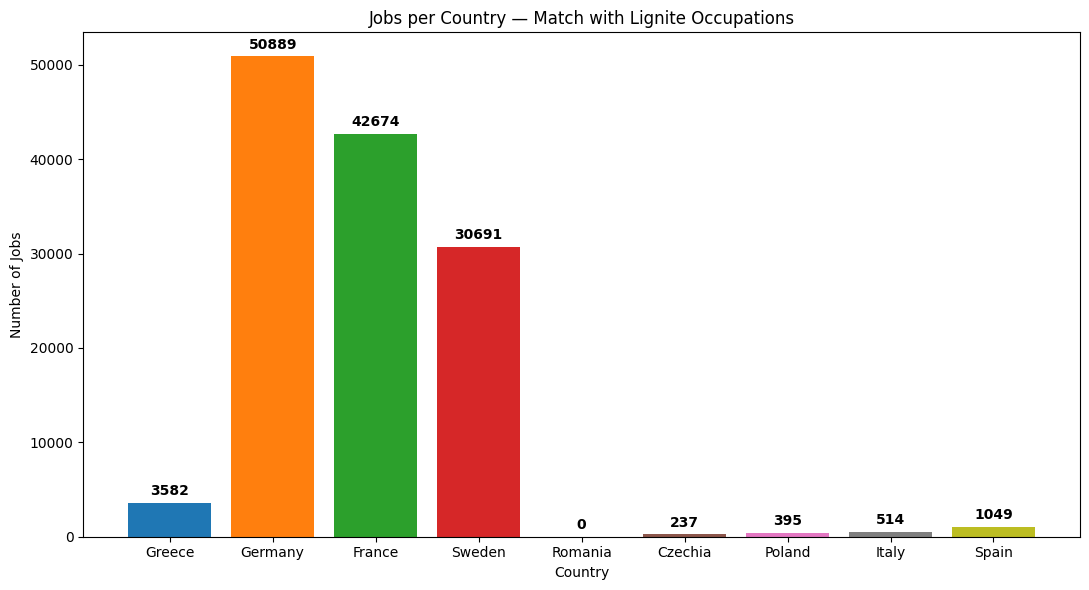

In [9]:
import json
import matplotlib.pyplot as plt

# Dictionary with file paths for each country
occupation_files = {
    "Greece":  "skillab_jobs_greece_lignite_occupations.json",
    "Germany": "skillab_jobs_germany_lignite_occupations.json",
    "France":  "skillab_jobs_france_lignite_occupations.json",
    "Sweden":  "skillab_jobs_sweden_lignite_occupations.json",
    "Romania": "skillab_jobs_romania_lignite_occupations.json",
    "Czechia": "skillab_jobs_czechia_lignite_occupations.json",
    "Poland":  "skillab_jobs_poland_lignite_occupations.json",
    "Italy":   "skillab_jobs_italy_lignite_occupations.json",
    "Spain":   "skillab_jobs_spain_lignite_occupations.json",
}

countries_to_plot = ["Greece", "Germany", "France", "Sweden", "Romania", "Czechia", "Poland", "Italy", "Spain"]

counts = {}
for country in countries_to_plot:
    file_path = occupation_files[country]
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    counts[country] = len(data)

# Prepare data for plotting
countries = list(counts.keys())
values = list(counts.values())

# Plot
plt.figure(figsize=(11, 6))
bars = plt.bar(countries, values, color=plt.cm.tab10.colors[:len(countries)])

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{value}",
        ha="center", va="bottom", fontweight="bold"
    )

plt.title("Jobs per Country — Match with Lignite Occupations")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

#Statistical Data

Συνολικός αριθμός εγγράφωνJobs που φορτώθηκαν: 130031

=== 1. ΠΛΗΘΟΣ ΘΕΣΕΩΝ ΕΡΓΑΣΙΑΣ ΑΝΑ ΧΩΡΑ ===
country_name
Germany    50889
France     42674
Sweden     30691
Greece      3582
Spain       1049
Italy        514
Poland       395
Czechia      237
Name: count, dtype: int64
--------------------------------------------------

=== 2. TOP 5 ΤΙΤΛΟΙ ΕΡΓΑΣΙΑΣ (TITLES) ΣΥΝΟΛΙΚΑ ===
title
Industrial mechanic (m/f/d) (industrial mechanic)                                 2428
Industrial maintenance technician (M/F)                                           1185
Locksmith (m/f/d) (company locksmith)                                              780
Electronics technician (m/f/d) (electronics technician - operating technology)     675
Building electrician (M/F)                                                         566
Name: count, dtype: int64

=== TOP 3 ΤΙΤΛΟΙ ΕΡΓΑΣΙΑΣ (TITLES) ΑΝΑ ΧΩΡΑ ===

[Χώρα: Czechia]
title
Electrical designer, Electronics engineers, designers, constructors       6
Electrici

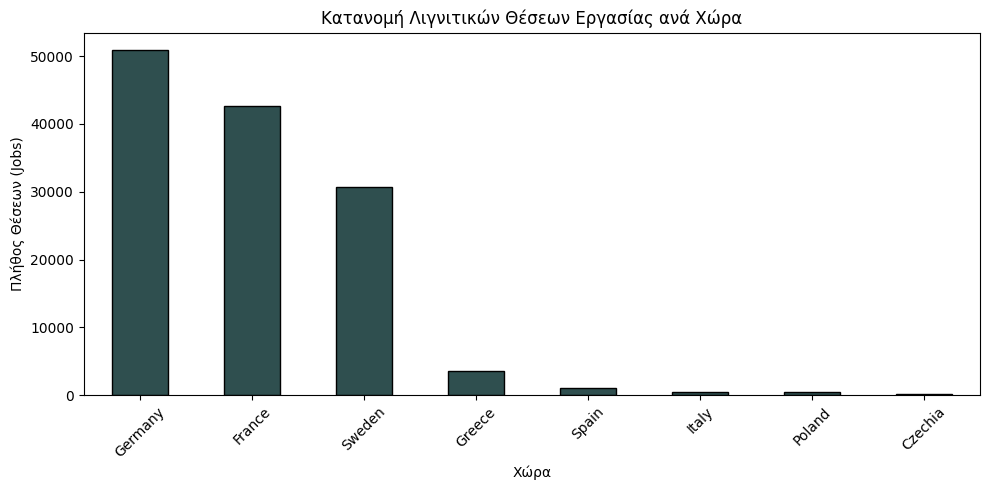

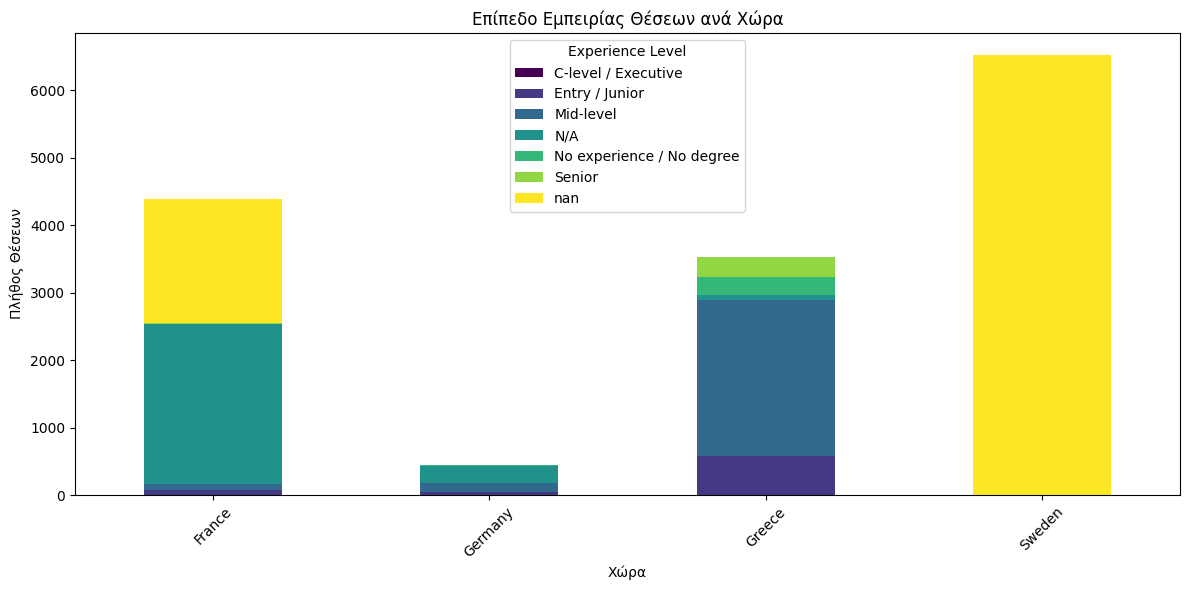

In [10]:
from collections import Counter
import json
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ορισμός του λεξικού με τα 9 αρχεία χωρών
occupation_files = {
    "Germany": "skillab_jobs_Germany_lignite_occupations.json",
    "Germany": "skillab_jobs_germany_lignite_occupations.json",
    "France": "skillab_jobs_france_lignite_occupations.json",
    "Sweden": "skillab_jobs_sweden_lignite_occupations.json",
    "Romania": "skillab_jobs_romania_lignite_occupations.json",
    "Czechia": "skillab_jobs_czechia_lignite_occupations.json",
    "Poland": "skillab_jobs_poland_lignite_occupations.json",
    "Italy": "skillab_jobs_italy_lignite_occupations.json",
    "Spain": "skillab_jobs_spain_lignite_occupations.json",
}

# 2. Φόρτωση και ενοποίηση των δεδομένων
all_jobs = []

for country, filename in occupation_files.items():
    if os.path.exists(filename):
        with open(filename, "r", encoding="utf-8") as f:
            jobs_data = json.load(f)
            for job in jobs_data:
                job["country_name"] = country  # Προσθήκη στήλης χώρας
                all_jobs.append(job)
    else:
        print(f"Προειδοποίηση: Το αρχείο {filename} δεν βρέθηκε.")

df = pd.DataFrame(all_jobs)
print(f"Συνολικός αριθμός εγγράφωνJobs που φορτώθηκαν: {len(df)}\n")

# ==============================================================================
# A. ΠΕΡΙΓΡΑΦΙΚΑ ΣΤΑΤΙΣΤΙΚΑ ΘΕΣΕΩΝ ΕΡΓΑΣΙΑΣ (TITLES) & ΕΠΑΓΓΕΛΜΑΤΩΝ (OCCUPATIONS)
# ==============================================================================

# 1. Συνολικό Πλήθος Θέσεων ανά Χώρα
print("=== 1. ΠΛΗΘΟΣ ΘΕΣΕΩΝ ΕΡΓΑΣΙΑΣ ΑΝΑ ΧΩΡΑ ===")
print(df["country_name"].value_counts())
print("-" * 50)

# 2. Top 5 Τίτλοι Εργασίας (Job Titles) Συνολικά & ανά Χώρα
print("\n=== 2. TOP 5 ΤΙΤΛΟΙ ΕΡΓΑΣΙΑΣ (TITLES) ΣΥΝΟΛΙΚΑ ===")
print(df["title"].value_counts().head(5))

print("\n=== TOP 3 ΤΙΤΛΟΙ ΕΡΓΑΣΙΑΣ (TITLES) ΑΝΑ ΧΩΡΑ ===")
for country, group in df.groupby("country_name"):
    print(f"\n[Χώρα: {country}]")
    print(group["title"].value_counts().head(3).to_string())

# 3. Top ESCO Occupations / ISCO URIs ανά Χώρα
print("\n" + "=" * 50)
print("=== 3. TOP 5 ESCO OCCUPATION URIs ΑΝΑ ΧΩΡΑ ===")
for country, group in df.groupby("country_name"):
    all_occs = [
        occ for sublist in group["occupations"].dropna() for occ in sublist
    ]
    occ_counts = Counter(all_occs).most_common(5)
    print(f"\n[Χώρα: {country}]")
    for occ_uri, count in occ_counts:
        print(f"  - {occ_uri}: {count} εμφανίσεις")

# ==============================================================================
# B. ΠΕΡΙΖΗΤΗΤΑ SKILLS (SKILL URIS) ΑΝΑ ΧΩΡΑ & ΣΥΝΟΛΙΚΑ
# ==============================================================================
print("\n" + "=" * 50)
print("=== 4. TOP 5 ZΗΤΟΥΜΕΝΑ SKILLS (URIs) ΑΝΑ ΧΩΡΑ ===")

stats_skills_by_country = {}

for country, group in df.groupby("country_name"):
    all_skills = [
        skill for sublist in group["skills"].dropna() for skill in sublist
    ]
    skill_counts = Counter(all_skills).most_common(5)
    stats_skills_by_country[country] = skill_counts

    print(f"\n[Χώρα: {country}]")
    for skill_uri, count in skill_counts:
        print(f"  - {skill_uri}: {count} εμφανίσεις")

# ==============================================================================
# Γ. ΓΡΑΦΗΜΑΤΑ ΓΙΑ ΤΟ REPORT
# ==============================================================================

# Γράφημα 1: Κατανομή Θέσεων Εργασίας ανά Χώρα
plt.figure(figsize=(10, 5))
df["country_name"].value_counts().plot(
    kind="bar", color="darkslategrey", edgecolor="black"
)
plt.title("Κατανομή Λιγνιτικών Θέσεων Εργασίας ανά Χώρα")
plt.xlabel("Χώρα")
plt.ylabel("Πλήθος Θέσεων (Jobs)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("jobs_distribution_per_country.png")
plt.show()

# Γράφημα 2: Κατανομή Επιπέδου Εμπειρίας (Experience Level) ανά Χώρα
if "experience_level" in df.columns:
    exp_ct = pd.crosstab(df["country_name"], df["experience_level"])
    exp_ct.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
    plt.title("Επίπεδο Εμπειρίας Θέσεων ανά Χώρα")
    plt.xlabel("Χώρα")
    plt.ylabel("Πλήθος Θέσεων")
    plt.legend(title="Experience Level")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("experience_level_per_country.png")
    plt.show()

#Lignite Profiles Filtering from Skillab API

#Greece

In [12]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_greece_lignite_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Greece"]

# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
lignite_occupation_uris_set = set(lignite_occupation_uris)
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

OCCUPATION_URIS = lignite_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Greece' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Greece" and profile.get("country") != "Greece":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & lignite_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} lignite occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Greece]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Greece + lignite occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Greece'], occupation_uris=(122 lignite occupation URIs, logic=or)


Fetching profiles [Greece]: 100%|██████████| 3247/3247 [09:32<00:00,  5.67profile/s, matched=3247, pages=65]

✅ API reported total profiles returned by server-side filters: 3247
✅ Profiles fetched/inspected: 3247
✅ Profiles that passed the client-side check (Greece + lignite occupation): 3247
✅ Saved profile data to skillab_profiles_greece_lignite_occupations.json


#Germany

In [13]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_germany_lignite_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Germany"]

# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
lignite_occupation_uris_set = set(lignite_occupation_uris)
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

OCCUPATION_URIS = lignite_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Germany' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Germany" and profile.get("country") != "Germany":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & lignite_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} lignite occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Germany]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Germany + lignite occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Germany'], occupation_uris=(122 lignite occupation URIs, logic=or)


Fetching profiles [Germany]: 100%|██████████| 25729/25729 [44:29<00:00,  9.64profile/s, matched=25729, pages=515]


✅ API reported total profiles returned by server-side filters: 25729
✅ Profiles fetched/inspected: 25729
✅ Profiles that passed the client-side check (Germany + lignite occupation): 25729
✅ Saved profile data to skillab_profiles_germany_lignite_occupations.json


#France

In [23]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_france_lignite_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["France"]

# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
lignite_occupation_uris_set = set(lignite_occupation_uris)
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

OCCUPATION_URIS = lignite_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'France' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "France" and profile.get("country") != "France":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & lignite_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} lignite occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [France]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (France + lignite occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['France'], occupation_uris=(122 lignite occupation URIs, logic=or)


Fetching profiles [France]: 100%|██████████| 45277/45277 [1:13:00<00:00, 10.34profile/s, matched=45277, pages=906]


✅ API reported total profiles returned by server-side filters: 45277
✅ Profiles fetched/inspected: 45277
✅ Profiles that passed the client-side check (France + lignite occupation): 45277
✅ Saved profile data to skillab_profiles_france_lignite_occupations.json


#Sweden

In [21]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_sweden_lignite_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Sweden"]

# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
lignite_occupation_uris_set = set(lignite_occupation_uris)
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

OCCUPATION_URIS = lignite_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Sweden' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Sweden" and profile.get("country") != "Sweden":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & lignite_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} lignite occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Sweden]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Sweden + lignite occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Sweden'], occupation_uris=(122 lignite occupation URIs, logic=or)


Fetching profiles [Sweden]: 100%|██████████| 9105/9105 [19:56<00:00,  7.61profile/s, matched=9105, pages=183]


✅ API reported total profiles returned by server-side filters: 9105
✅ Profiles fetched/inspected: 9105
✅ Profiles that passed the client-side check (Sweden + lignite occupation): 9105
✅ Saved profile data to skillab_profiles_sweden_lignite_occupations.json


#Poland

In [14]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_poland_lignite_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Poland"]

# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
lignite_occupation_uris_set = set(lignite_occupation_uris)
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

OCCUPATION_URIS = lignite_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Poland' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Poland" and profile.get("country") != "Poland":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & lignite_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} lignite occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Poland]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Poland + lignite occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Poland'], occupation_uris=(122 lignite occupation URIs, logic=or)


Fetching profiles [Poland]: 100%|██████████| 8735/8735 [14:53<00:00,  9.77profile/s, matched=8735, pages=175]


✅ API reported total profiles returned by server-side filters: 8735
✅ Profiles fetched/inspected: 8735
✅ Profiles that passed the client-side check (Poland + lignite occupation): 8735
✅ Saved profile data to skillab_profiles_poland_lignite_occupations.json


#Czechia "Czech Republic"

In [22]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_czechia_lignite_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Czech Republic"]

# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
lignite_occupation_uris_set = set(lignite_occupation_uris)
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

OCCUPATION_URIS = lignite_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Czech Republic' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Czech Republic" and profile.get("country") != "Czech Republic":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & lignite_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} lignite occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Czech Republic]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Czech Republic + lignite occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Czech Republic'], occupation_uris=(122 lignite occupation URIs, logic=or)


Fetching profiles [Czech Republic]: 100%|██████████| 3038/3038 [05:53<00:00,  8.60profile/s, matched=3038, pages=61]

✅ API reported total profiles returned by server-side filters: 3038
✅ Profiles fetched/inspected: 3038
✅ Profiles that passed the client-side check (Czech Republic + lignite occupation): 3038
✅ Saved profile data to skillab_profiles_czechia_lignite_occupations.json


#Romania

In [16]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_romania_lignite_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Romania"]

# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
lignite_occupation_uris_set = set(lignite_occupation_uris)
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

OCCUPATION_URIS = lignite_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Romania' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Romania" and profile.get("country") != "Romania":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & lignite_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} lignite occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Romania]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Romania + lignite occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Romania'], occupation_uris=(122 lignite occupation URIs, logic=or)


Fetching profiles [Romania]:  44%|████▎     | 2250/5161 [07:46<05:26,  8.92profile/s, matched=2250, pages=45]


⚠️  Page 46 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


Fetching profiles [Romania]: 100%|██████████| 5161/5161 [18:14<00:00,  4.71profile/s, matched=5161, pages=104]


✅ API reported total profiles returned by server-side filters: 5161
✅ Profiles fetched/inspected: 5161
✅ Profiles that passed the client-side check (Romania + lignite occupation): 5161
✅ Saved profile data to skillab_profiles_romania_lignite_occupations.json


#Italy

In [17]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_italy_lignite_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Italy"]

# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
lignite_occupation_uris_set = set(lignite_occupation_uris)
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

OCCUPATION_URIS = lignite_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Italy' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Italy" and profile.get("country") != "Italy":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & lignite_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} lignite occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Italy]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Italy + lignite occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Italy'], occupation_uris=(122 lignite occupation URIs, logic=or)


Fetching profiles [Italy]: 100%|██████████| 23301/23301 [39:58<00:00,  9.72profile/s, matched=23301, pages=467]


✅ API reported total profiles returned by server-side filters: 23301
✅ Profiles fetched/inspected: 23301
✅ Profiles that passed the client-side check (Italy + lignite occupation): 23301
✅ Saved profile data to skillab_profiles_italy_lignite_occupations.json


#Spain

In [18]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd
from google.colab import userdata

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_profiles_spain_lignite_occupations.json"
PAGE_SIZE = 50
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_PROFILES = None

# ── Filters — σωστά ονόματα πεδίων σύμφωνα με το /api/docs ────────────────
COUNTRIES = ["Spain"]

# Φόρτωση της λίστας lignite occupations (ESCO)
lignite_occ_df = pd.read_csv("/content/lignite_occupations.csv")
lignite_occupation_uris = lignite_occ_df["conceptUri"].dropna().unique().tolist()
lignite_occupation_uris_set = set(lignite_occupation_uris)
print(f"Επίσημα lignite occupation URIs: {len(lignite_occupation_uris)}")

OCCUPATION_URIS = lignite_occupation_uris
OCCUPATION_URIS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def profile_matches_filters(profile):
    """Client-side ασφάλεια: location/country == 'Spain' ΚΑΙ τουλάχιστον ένα
    κοινό occupation_uri με τη λίστα των πράσινων επαγγελμάτων."""
    if profile.get("location") != "Spain" and profile.get("country") != "Spain":
        return False
    profile_uris = set(profile.get("occupation_uris") or [])
    return bool(profile_uris & lignite_occupation_uris_set)


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

data = {
    "countries": COUNTRIES,
    "occupation_uris": OCCUPATION_URIS,
    "occupation_uris_logic": OCCUPATION_URIS_LOGIC,
}

all_profiles = []
page = 1
total_count = None
raw_fetched = 0
skipped_mismatch = 0
pbar = None

print("\n📡 Fetching /api/profiles")
print(f"   filters: countries={COUNTRIES}, occupation_uris=({len(OCCUPATION_URIS)} lignite occupation URIs, logic={OCCUPATION_URIS_LOGIC})")
print("=" * 60)

try:
    while True:
        response = None
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                response = requests.post(
                    f"{API_BASE_URL}/profiles",
                    params={"page": page, "page_size": PAGE_SIZE},
                    headers=headers,
                    data=data,
                    verify=False,
                    timeout=REQUEST_TIMEOUT
                )
                break
            except requests.exceptions.RequestException as e:
                wait = RETRY_BACKOFF * attempt
                print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                sleep(wait)

        if response is None:
            print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
            break

        if response.status_code != 200:
            print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
            break

        page_data = response.json()
        items = page_data.get("items", [])
        total_count = page_data.get("count", total_count)

        if pbar is None:
            pbar = tqdm(total=total_count, desc="Fetching profiles [Spain]", unit="profile")

        if not items:
            print("✅ Empty page — no more results.")
            break

        raw_fetched += len(items)

        for profile in items:
            if profile_matches_filters(profile):
                all_profiles.append(profile)
            else:
                skipped_mismatch += 1

        pbar.update(len(items))
        pbar.set_postfix(pages=page, matched=len(all_profiles))

        if MAX_PROFILES and len(all_profiles) >= MAX_PROFILES:
            print(f"\n🛑 Reached cap of {MAX_PROFILES} matching profiles — stopping.")
            break

        if total_count is not None and raw_fetched >= total_count:
            break

        page += 1
        sleep(0.3)
finally:
    if pbar is not None:
        pbar.close()

print("=" * 60)
print(f"✅ API reported total profiles returned by server-side filters: {total_count}")
print(f"✅ Profiles fetched/inspected: {raw_fetched}")
print(f"✅ Profiles that passed the client-side check (Spain + lignite occupation): {len(all_profiles)}")
if skipped_mismatch:
    print(f"ℹ️  {skipped_mismatch} profiles returned by the server did not pass the client-side check.")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_profiles, f, indent=4, ensure_ascii=False)

print(f"✅ Saved profile data to {OUTPUT_FILE}")

Επίσημα lignite occupation URIs: 122
Authenticating...
Token acquired.

📡 Fetching /api/profiles
   filters: countries=['Spain'], occupation_uris=(122 lignite occupation URIs, logic=or)


Fetching profiles [Spain]: 100%|██████████| 21851/21851 [36:04<00:00, 10.10profile/s, matched=21851, pages=438]


✅ API reported total profiles returned by server-side filters: 21851
✅ Profiles fetched/inspected: 21851
✅ Profiles that passed the client-side check (Spain + lignite occupation): 21851
✅ Saved profile data to skillab_profiles_spain_lignite_occupations.json


#Plot Lignite Profiles per Country

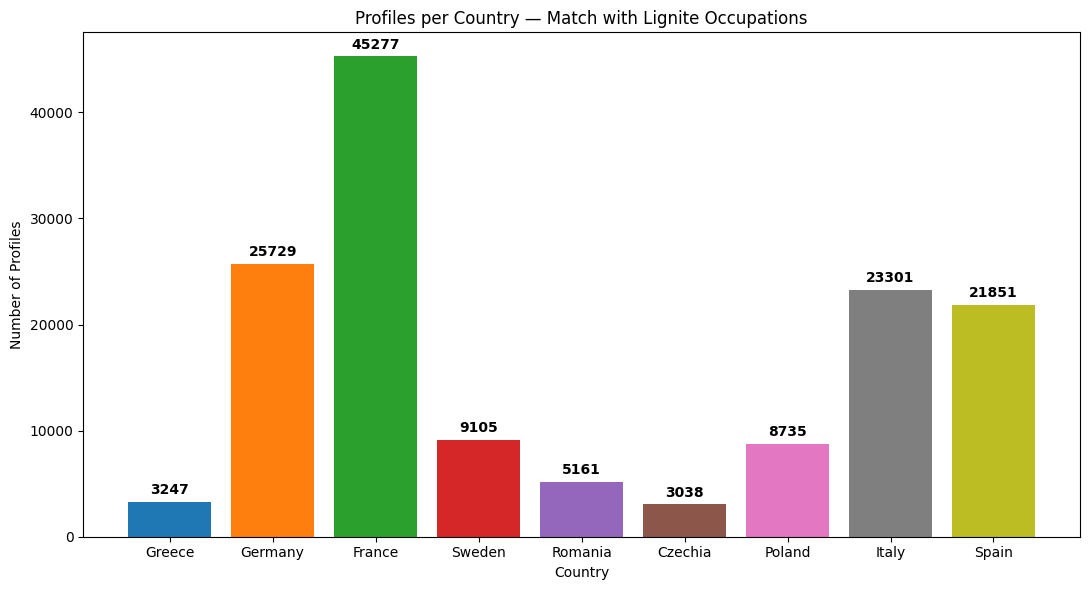

In [24]:
import json
import matplotlib.pyplot as plt

# Dictionary with file paths for each country
occupation_files = {
    "Greece":  "skillab_profiles_greece_lignite_occupations.json",
    "Germany": "skillab_profiles_germany_lignite_occupations.json",
    "France":  "skillab_profiles_france_lignite_occupations.json",
    "Sweden":  "skillab_profiles_sweden_lignite_occupations.json",
    "Romania": "skillab_profiles_romania_lignite_occupations.json",
    "Czechia": "skillab_profiles_czechia_lignite_occupations.json",
    "Poland":  "skillab_profiles_poland_lignite_occupations.json",
    "Italy":   "skillab_profiles_italy_lignite_occupations.json",
    "Spain":   "skillab_profiles_spain_lignite_occupations.json",
}

# Only the countries we want in this plot (original 6 + Italy + Poland)
countries_to_plot = ["Greece", "Germany", "France", "Sweden", "Romania", "Czechia", "Poland","Italy", "Spain"]

# Count number of records (profiles) in each file
counts = {}
for country in countries_to_plot:
    file_path = occupation_files[country]
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    counts[country] = len(data)  # assumes each file is a JSON list of profiles

# Prepare data for plotting
countries = list(counts.keys())
values = list(counts.values())

# Plot
plt.figure(figsize=(11, 6))
bars = plt.bar(countries, values, color=plt.cm.tab10.colors[:len(countries)])

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{value}",
        ha="center", va="bottom", fontweight="bold"
    )

plt.title("Profiles per Country — Match with Lignite Occupations")
plt.xlabel("Country")
plt.ylabel("Number of Profiles")
plt.tight_layout()
plt.show()